# Hebbian attractor demo with output-weight transforms

This notebook explores how perturbing stored patterns changes the attractor geometry.
It now also supports separate transforms for the output weights relative to the input weights,
including linear, rotational, and permutation variants.


In [112]:
import numpy as np
import matplotlib.pyplot as plt


In [113]:
def generate_patterns(distribution, num_patterns, pattern_size):
    if distribution == 'gaussian':
        return np.random.randn(num_patterns, pattern_size)
    if distribution == 'laplace':
        return np.random.laplace(loc=0.0, scale=1.0, size=(num_patterns, pattern_size))
    raise ValueError(f"Unsupported distribution type: {distribution}")


def build_diagonal_scaling(num_patterns, diagonal_deltas=None):
    scaling = np.eye(num_patterns)
    if diagonal_deltas is None:
        return scaling

    diagonal_deltas = np.asarray(diagonal_deltas, dtype=float)
    if diagonal_deltas.shape != (num_patterns,):
        raise ValueError(
            f"`diagonal_deltas` must have shape {(num_patterns,)}, got {diagonal_deltas.shape}."
        )
    return scaling + np.diag(diagonal_deltas)


def build_rotation_transform(num_patterns, rot_plane=(0, 1), rot_ang=0.0):
    i, j = rot_plane
    if i == j:
        raise ValueError("`rot_plane` must contain two distinct pattern indices.")
    if not (0 <= i < num_patterns and 0 <= j < num_patterns):
        raise ValueError(f"`rot_plane` indices must lie in [0, {num_patterns - 1}].")

    transform = np.eye(num_patterns)
    c = np.cos(rot_ang)
    s = np.sin(rot_ang)
    transform[[i, i, j, j], [i, j, i, j]] = [c, -s, s, c]
    return transform


def build_permutation_transform(num_patterns, perm_path, perm_mag):
    if perm_path is None or len(perm_path) < 2:
        raise ValueError("`perm_path` must contain at least two indices.")

    path = [int(idx) for idx in perm_path]
    if any(idx < 0 or idx >= num_patterns for idx in path):
        raise ValueError(f"`perm_path` indices must lie in [0, {num_patterns - 1}].")
    if len(set(path)) != len(path):
        raise ValueError("`perm_path` must not repeat indices; the cycle closes automatically.")

    transform = np.eye(num_patterns)
    for idx in path:
        transform[idx, idx] -= perm_mag

    for src, dst in zip(path, path[1:] + path[:1]):
        transform[src, dst] += perm_mag

    return transform


def build_output_transform(
    num_patterns,
    transform_kind='identity',
    linear_transform=None,
    rot_plane=(0, 1),
    rot_ang=0.0,
    perm_path=None,
    perm_mag=0.0,
):
    if transform_kind == 'identity':
        return np.eye(num_patterns)

    if transform_kind == 'linear':
        if linear_transform is None:
            raise ValueError("`linear_transform` must be provided when transform_kind='linear'.")
        linear_transform = np.asarray(linear_transform, dtype=float)
        if linear_transform.shape != (num_patterns, num_patterns):
            raise ValueError(
                f"`linear_transform` must have shape {(num_patterns, num_patterns)}, got {linear_transform.shape}."
            )
        return linear_transform

    if transform_kind == 'rotation':
        if linear_transform is not None:
            raise ValueError("Do not pass `linear_transform` when transform_kind='rotation'.")
        return build_rotation_transform(num_patterns, rot_plane=rot_plane, rot_ang=rot_ang)

    if transform_kind == 'permutation':
        if linear_transform is not None:
            raise ValueError("Do not pass `linear_transform` when transform_kind='permutation'.")
        return build_permutation_transform(num_patterns, perm_path=perm_path, perm_mag=perm_mag)

    raise ValueError(f"Unsupported transform_kind: {transform_kind}")


In [114]:
def run_dynamics(x0, W, phi, g=2, num_steps=100):
    x = x0
    xt = np.zeros((num_steps + 1, *x.shape))
    preacts = np.zeros((num_steps + 1, *x.shape))
    xt[0, :, :] = x
    preacts[0, :, :] = g * (x @ W)

    for t in range(1, num_steps + 1):
        h = g * (x @ W)
        preacts[t, :, :] = h
        x = phi(h)
        xt[t, :, :] = x

    return x, xt, preacts


def create_hebbian_weights(xi, pattern_weights=None, output_transform=None, normalize=True):
    num_patterns = xi.shape[0]

    if pattern_weights is None:
        pattern_weights = np.eye(num_patterns)
    else:
        pattern_weights = np.asarray(pattern_weights, dtype=float)
        if pattern_weights.shape != (num_patterns, num_patterns):
            raise ValueError(
                f"`pattern_weights` must have shape {(num_patterns, num_patterns)}, got {pattern_weights.shape}."
            )

    if output_transform is None:
        output_transform = np.eye(num_patterns)
    else:
        output_transform = np.asarray(output_transform, dtype=float)
        if output_transform.shape != (num_patterns, num_patterns):
            raise ValueError(
                f"`output_transform` must have shape {(num_patterns, num_patterns)}, got {output_transform.shape}."
            )

    output_patterns = output_transform @ xi
    W = output_patterns.T @ pattern_weights @ xi

    if normalize:
        W /= xi.shape[1]

    return W


In [115]:
phi = np.tanh
n = 10_000
p = 7
xi = generate_patterns('laplace', p, n)

n_k = 40
num_steps = 100
gain = 1.05
bnd_off_zero = 0.1
perturb_amp = 0.15

dim_to_perturb = [None] + list(range(p))

output_transform_kind = 'permutation' # 'identity'  # 'identity', 'linear', 'rotation', or 'permutation'
linear_transform = None
rot_plane = (0, 1)
rot_ang = 0.08
perm_path = [0, 1, 2]
perm_mag = 0.9


In [116]:
# Generate random initial states in the positive orthant and see where they converge.
k = np.random.rand(n_k, p) * (1 - bnd_off_zero) + bnd_off_zero
k = k / np.linalg.norm(k, axis=1, keepdims=True)
x0 = k @ xi

output_transform = build_output_transform(
    p,
    transform_kind=output_transform_kind,
    linear_transform=linear_transform,
    rot_plane=rot_plane,
    rot_ang=rot_ang,
    perm_path=perm_path,
    perm_mag=perm_mag,
)

all_preact_projs = []
all_projs = []

for this_dim_to_perturb in dim_to_perturb:
    diagonal_deltas = np.zeros(p)
    if this_dim_to_perturb is not None:
        diagonal_deltas[this_dim_to_perturb] = perturb_amp

    pattern_weights = build_diagonal_scaling(p, diagonal_deltas=diagonal_deltas)
    W = create_hebbian_weights(
        xi,
        pattern_weights=pattern_weights,
        output_transform=output_transform,
    )
    final_states, trajectories, preact_trajectories = run_dynamics(x0, W, phi, g=gain, num_steps=num_steps)
    all_preact_projs.append(preact_trajectories @ xi.T)
    all_projs.append(trajectories @ xi.T)

print('Output transform kind:', output_transform_kind)
print('Output transform matrix:')
print(output_transform)


Output transform kind: permutation
Output transform matrix:
[[0.1 0.9 0.  0.  0.  0.  0. ]
 [0.  0.1 0.9 0.  0.  0.  0. ]
 [0.9 0.  0.1 0.  0.  0.  0. ]
 [0.  0.  0.  1.  0.  0.  0. ]
 [0.  0.  0.  0.  1.  0.  0. ]
 [0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  0.  1. ]]


In [119]:
def plot_projection_trajectories(all_projs_, dim_to_perturb, idx0=2, perturbs_to_display=None):
    colors = ['k', 'r', 'g', 'b']
    if perturbs_to_display is None:
        perturbs_to_display = dim_to_perturb[:4]
    plt.figure(figsize=(18, 6))
    lim = 1.1 * np.max(np.abs(all_projs_[:, idx0:]))

    for dd, this_dim_to_perturb in enumerate(perturbs_to_display):
        projs = all_projs_[dd][idx0:]
        for i in range(projs.shape[1]):
            plt.subplot(1, 3, 1)
            plt.plot(projs[:, i, 0], projs[:, i, 1], '.-', alpha=0.1, color=colors[dd])
            plt.plot(projs[-1, i, 0], projs[-1, i, 1], 'x', alpha=0.1, color=colors[dd])
            plt.plot(projs[0, i, 0], projs[0, i, 1], 'o', alpha=0.1, color=colors[dd])
            plt.xlim(0, lim)
            plt.ylim(0, lim)
            plt.xlabel('projection on pattern 1 [au]', fontsize=12)
            plt.ylabel('projection on pattern 2 [au]', fontsize=12)

            plt.subplot(1, 3, 2)
            plt.plot(projs[:, i, 1], projs[:, i, 2], '.-', alpha=0.1, color=colors[dd])
            plt.plot(projs[-1, i, 1], projs[-1, i, 2], 'x', alpha=0.1, color=colors[dd])
            plt.plot(projs[0, i, 1], projs[0, i, 2], 'o', alpha=0.1, color=colors[dd])
            plt.xlim(0, lim)
            plt.ylim(0, lim)
            plt.xlabel('projection on pattern 2 [au]', fontsize=12)
            plt.ylabel('projection on pattern 3 [au]', fontsize=12)

            ax = plt.subplot(1, 3, 3, projection='3d')
            ax.plot(projs[:, i, 0], projs[:, i, 1], projs[:, i, 2], '.-', alpha=0.1, color=colors[dd])
            ax.plot(projs[-1, i, 0], projs[-1, i, 1], projs[-1, i, 2], 'x', alpha=0.1, color=colors[dd])
            ax.plot(projs[0, i, 0], projs[0, i, 1], projs[0, i, 2], 'o', alpha=0.1, color=colors[dd])
            ax.set_xlim(0, lim)
            ax.set_ylim(0, lim)
            ax.set_zlim(0, lim)
            ax.view_init(15, 30, 0)

    plt.subplot(1, 3, 1)
    plt.arrow(0, 0, lim * 0.8, 0, head_width=lim * 0.05, head_length=lim * 0.1, fc=colors[1], ec=colors[1])
    plt.arrow(0, 0, 0, lim * 0.8, head_width=lim * 0.05, head_length=lim * 0.1, fc=colors[2], ec=colors[2])
    plt.box(False)

    plt.subplot(1, 3, 2)
    plt.arrow(0, 0, lim * 0.8, 0, head_width=lim * 0.05, head_length=lim * 0.1, fc=colors[2], ec=colors[2])
    plt.arrow(0, 0, 0, lim * 0.8, head_width=lim * 0.05, head_length=lim * 0.1, fc=colors[3], ec=colors[3])
    plt.box(False)

    ax = plt.subplot(1, 3, 3, projection='3d')
    for dd, this_dim_to_perturb in enumerate(dim_to_perturb[:4]):
        ax.quiver(
            0,
            0,
            0,
            lim * 0.8 if this_dim_to_perturb == 0 else 0,
            lim * 0.8 if this_dim_to_perturb == 1 else 0,
            lim * 0.8 if this_dim_to_perturb == 2 else 0,
            arrow_length_ratio=0.1,
            color=colors[dd],
        )

    plt.show()


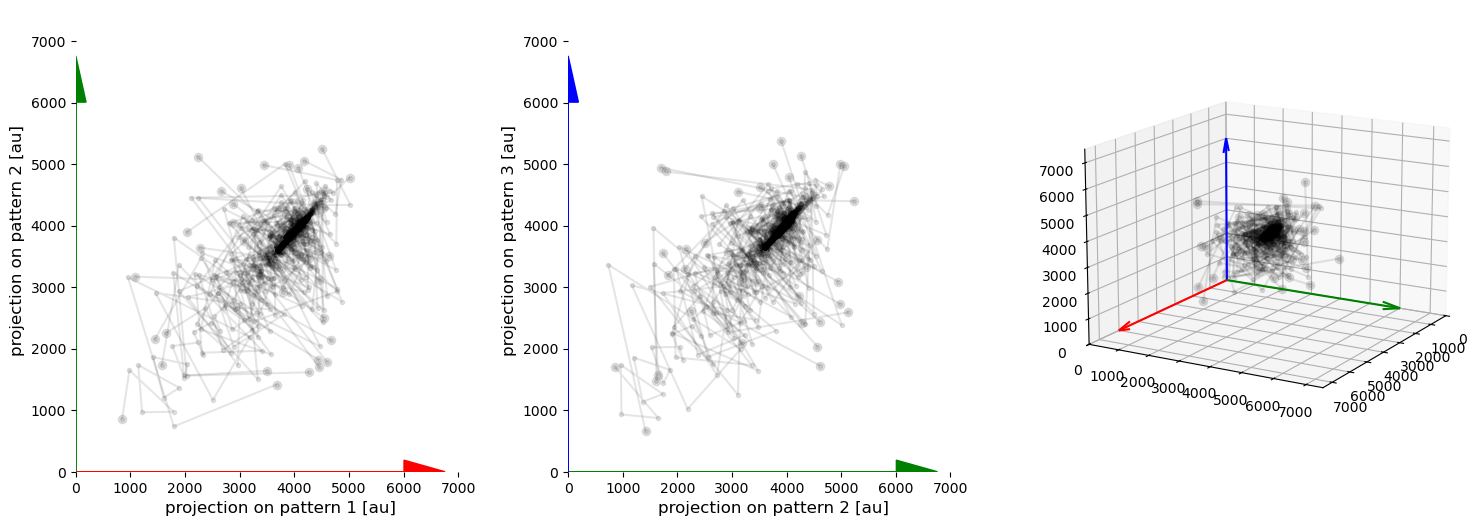

In [121]:
# all_projs_ = np.asarray(all_preact_projs)
all_projs_ = np.asarray(all_projs)

# plot_projection_trajectories(all_projs_, dim_to_perturb, idx0=2)
plot_projection_trajectories(all_projs_, dim_to_perturb, idx0=2, perturbs_to_display=[None])